<a href="https://colab.research.google.com/github/MarcGaac/Stat-Theory/blob/main/FA_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

8.18

--- All Possible Samples (Cols A, B, C) ---
 A  B  mean (C)
 9  9       9.0
 9 12      10.5
 9 15      12.0
12  9      10.5
12 12      12.0
12 15      13.5
15  9      12.0
15 12      13.5
15 15      15.0


--- Sampling Distribution (Cols D, E, F, G) ---
 xbar (D)  p(xbar) (E)  xbar * p(xbar) (F)  xbar^2 * p(xbar) (G)
      9.0     0.111111            1.000000                   9.0
     10.5     0.222222            2.333333                  24.5
     12.0     0.333333            4.000000                  48.0
     13.5     0.222222            3.000000                  40.5
     15.0     0.111111            1.666667                  25.0


--- Summary & Proof ---
Sum of Column F (mu_xbar): 11.999999999999998
Sum of Column G: 147.0
Variance of sampling distribution (var_xbar): 147.0 - 11.999999999999998^2 = 3.0000000000000284
-------------------------
Population mean (mu): 12.0
Population variance (sigma^2): 6.0
sigma^2 / n: 6.0 / 2 = 3.0


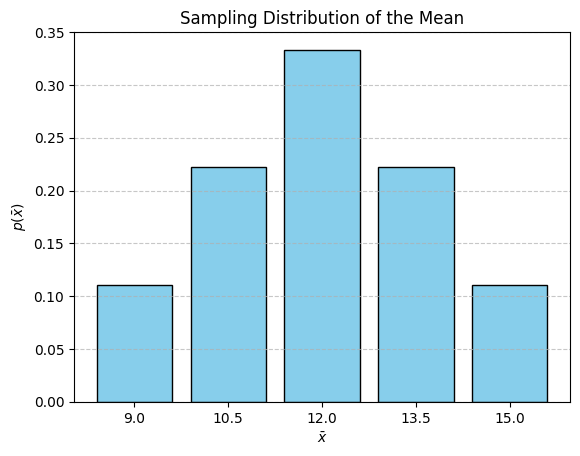

In [1]:
import pandas as pd
import numpy as np
import itertools
import matplotlib.pyplot as plt

# 1. Define Population and all samples of size n=2
population = [9, 12, 15]
samples = list(itertools.product(population, repeat=2))

# 2. Create the Sample Pairs and Means table (Columns A, B, C)
df_samples = pd.DataFrame(samples, columns=['A', 'B'])
df_samples['mean (C)'] = df_samples.mean(axis=1)

print("--- All Possible Samples (Cols A, B, C) ---")
print(df_samples.to_string(index=False))
print("\n")

# 3. Create the Sampling Distribution table (Columns D, E, F, G)
# Count frequencies of each unique mean
xbar_counts = df_samples['mean (C)'].value_counts().sort_index()
total_samples = len(df_samples)

df_dist = pd.DataFrame({
    'xbar (D)': xbar_counts.index,
    'p(xbar) (E)': xbar_counts.values / total_samples
})

# Calculate expected values
df_dist['xbar * p(xbar) (F)'] = df_dist['xbar (D)'] * df_dist['p(xbar) (E)']
df_dist['xbar^2 * p(xbar) (G)'] = (df_dist['xbar (D)']**2) * df_dist['p(xbar) (E)']

print("--- Sampling Distribution (Cols D, E, F, G) ---")
print(df_dist.to_string(index=False))
print("\n")

# 4. Prove the theorems: mu_xbar = mu, and var_xbar = var / 2
mu_xbar = df_dist['xbar * p(xbar) (F)'].sum()
sum_sq_xbar = df_dist['xbar^2 * p(xbar) (G)'].sum()
var_xbar = sum_sq_xbar - (mu_xbar ** 2)

pop_mu = np.mean(population)
pop_var = np.var(population) # Population variance (ddof=0)

print("--- Summary & Proof ---")
print(f"Sum of Column F (mu_xbar): {mu_xbar}")
print(f"Sum of Column G: {sum_sq_xbar}")
print(f"Variance of sampling distribution (var_xbar): {sum_sq_xbar} - {mu_xbar}^2 = {var_xbar}")
print("-" * 25)
print(f"Population mean (mu): {pop_mu}")
print(f"Population variance (sigma^2): {pop_var}")
print(f"sigma^2 / n: {pop_var} / 2 = {pop_var / 2}")

# 5. Plot the sampling distribution (Equivalent to Excel Chart Wizard)
plt.bar(df_dist['xbar (D)'].astype(str), df_dist['p(xbar) (E)'], color='skyblue', edgecolor='black')
plt.title("Sampling Distribution of the Mean")
plt.xlabel(r'$\bar{x}$')
plt.ylabel(r'$p(\bar{x})$')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

8.21

In [2]:
import numpy as np
import itertools
import pandas as pd

# Define the population and sample size
population = [3, 7, 11, 15]
n = 2

# (a) Calculate Population Mean
mu = np.mean(population)
print(f"(a) Population Mean (\u03bc): {mu}")

# (b) Calculate Population Standard Deviation (ddof=0 for population)
sigma = np.std(population, ddof=0)
print(f"(b) Population Standard Deviation (\u03c3): {sigma:.4f}")

# Generate all possible samples of size 2 (with replacement)
all_samples = list(itertools.product(population, repeat=n))

# Calculate the mean of each sample
sample_means = [np.mean(sample) for sample in all_samples]

# (c) Mean of the sampling distribution of means
mu_xbar = np.mean(sample_means)
print(f"(c) Mean of Sampling Distribution (\u03bc_\u0304x): {mu_xbar}")

# (d) Standard deviation of the sampling distribution of means
sigma_xbar = np.std(sample_means, ddof=0)
print(f"(d) Standard Deviation of Sampling Distribution (\u03c3_\u0304x): {sigma_xbar:.4f}")

print("\n--- Verification using formulas ---")
print(f"Verify \u03bc_\u0304x == \u03bc: {mu_xbar} == {mu}")
print(f"Verify \u03c3_\u0304x == \u03c3/\u221an: {sigma_xbar:.4f} == {(sigma / np.sqrt(n)):.4f}")

# Optional: Displaying the full sampling distribution as a DataFrame
df_dist = pd.DataFrame({'Sample': all_samples, 'Sample Mean': sample_means})
# print(df_dist)

(a) Population Mean (μ): 9.0
(b) Population Standard Deviation (σ): 4.4721
(c) Mean of Sampling Distribution (μ_̄x): 9.0
(d) Standard Deviation of Sampling Distribution (σ_̄x): 3.1623

--- Verification using formulas ---
Verify μ_̄x == μ: 9.0 == 9.0
Verify σ_̄x == σ/√n: 3.1623 == 3.1623


8.34

In [3]:
from scipy.stats import binom

n = 200
p = 0.5

# (a) less than 40% boys (< 80 boys) -> <= 79
k_a = int(0.40 * n) - 1
prob_a = binom.cdf(k_a, n, p)

# (b) between 43% and 57% girls (86 to 114 inclusive)
k_b_lower = int(0.43 * n)
k_b_upper = int(0.57 * n)
prob_b = binom.cdf(k_b_upper, n, p) - binom.cdf(k_b_lower - 1, n, p)

# (c) more than 54% boys (> 108) -> 1 - P(<=108)
k_c = int(0.54 * n)
prob_c = 1 - binom.cdf(k_c, n, p)

print(f"(a) P(X < 80): {prob_a:.6f}")
print(f"(b) P(86 <= X <= 114): {prob_b:.6f}")
print(f"(c) P(X > 108): {prob_c:.6f}")

(a) P(X < 80): 0.001817
(b) P(86 <= X <= 114): 0.951999
(c) P(X > 108): 0.114623


8.49

--- Sampling Distribution of the Means ---
 Sample Mean  Probability
         6.0         0.01
         7.5         0.04
         9.0         0.12
        10.5         0.20
        12.0         0.26
        13.5         0.20
        15.0         0.12
        16.5         0.04
        18.0         0.01

--- Summary Statistics ---
Mean of sampling distribution (μ_̄x): 12.0
Variance of sampling distribution (σ²_̄x): 5.4
   (Notice that 5.4 is exactly half of the population variance, 10.8)


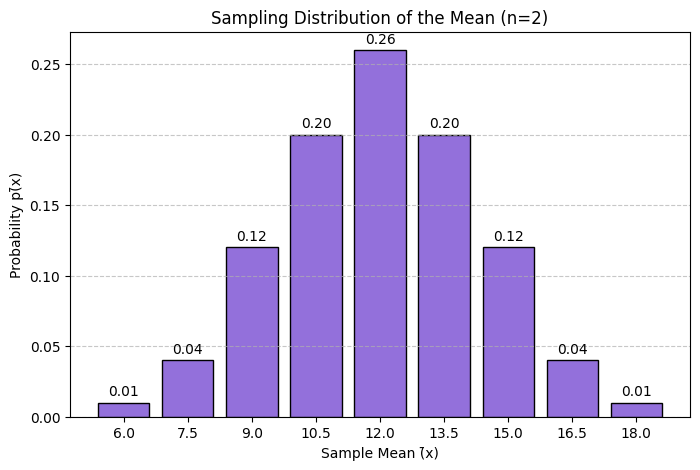

In [4]:
import pandas as pd
import numpy as np
import itertools
import matplotlib.pyplot as plt

# 1. Define Population values and probabilities
x_vals = [6, 9, 12, 15, 18]
p_vals = [0.1, 0.2, 0.4, 0.2, 0.1]
prob_dict = dict(zip(x_vals, p_vals))

# 2. Generate all 25 possible samples of size n=2
samples = list(itertools.product(x_vals, repeat=2))

# 3. Calculate means and probabilities for each sample
sample_data = []
for s in samples:
    mean_val = sum(s) / len(s)
    prob_val = prob_dict[s[0]] * prob_dict[s[1]]
    sample_data.append({'Sample (x1, x2)': s, 'Sample Mean': mean_val, 'Probability': prob_val})

df_samples = pd.DataFrame(sample_data)

# 4. Group by the Sample Mean to create the final Sampling Distribution
sampling_dist = df_samples.groupby('Sample Mean')['Probability'].sum().reset_index()

print("--- Sampling Distribution of the Means ---")
print(sampling_dist.to_string(index=False))

# 5. Verify the Theorems:
# mu_xbar = sum(mean * probability)
mu_xbar = (sampling_dist['Sample Mean'] * sampling_dist['Probability']).sum()

# var_xbar = sum((mean - mu_xbar)^2 * probability)
var_xbar = (((sampling_dist['Sample Mean'] - mu_xbar)**2) * sampling_dist['Probability']).sum()

print("\n--- Summary Statistics ---")
print(f"Mean of sampling distribution (\u03bc_\u0304x): {mu_xbar:.1f}")
print(f"Variance of sampling distribution (\u03c3\u00b2_\u0304x): {var_xbar:.1f}")
print(f"   (Notice that {var_xbar:.1f} is exactly half of the population variance, 10.8)")

# 6. Plot the distribution
plt.figure(figsize=(8, 5))
plt.bar(sampling_dist['Sample Mean'].astype(str), sampling_dist['Probability'],
        color='mediumpurple', edgecolor='black', width=0.8)
plt.title('Sampling Distribution of the Mean (n=2)')
plt.xlabel('Sample Mean (\u0304x)')
plt.ylabel('Probability p(\u0304x)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add text labels on top of the bars
for i, prob in enumerate(sampling_dist['Probability']):
    plt.text(i, prob + 0.005, f"{prob:.2f}", ha='center')

plt.savefig('sampling_dist.png')